In [1]:
import os
import pandas as pd

BASE = "/kaggle/input/competitions/rsna-knee-abnormality-detection"

print(os.listdir(BASE))

dataset = pd.read_csv(f"{BASE}/sample_submission.csv")

print("row:", len(dataset))
print("column:", list(dataset.columns))

target_cols = [c for c in dataset.columns if c != "StudyInstanceUID"]
dataset[target_cols] = 0.5

dataset.to_csv("submission.csv", index=False)

print("created:", len(dataset), "row,", len(target_cols), "target")
print(dataset.head())

['test_series.csv', 'train_series.csv', 'sample_submission.csv', 'test_series', 'train_series', 'train.csv', 'test.csv']
row: 3
column: ['StudyInstanceUID', 'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']
created: 3 row, 12 target
                                    StudyInstanceUID  ACL  MCL  \
0  1.2.826.0.1.3680043.8.498.10047035057544427318...  0.5  0.5   
1  1.2.826.0.1.3680043.8.498.10062861783145312629...  0.5  0.5   
2  1.2.826.0.1.3680043.8.498.10067514707072572280...  0.5  0.5   

   Medial Meniscus  Lateral Meniscus  Medial OA  Lateral OA  PF OA  Effusion  \
0              0.5               0.5        0.5         0.5    0.5       0.5   
1              0.5               0.5        0.5         0.5    0.5       0.5   
2              0.5               0.5        0.5         0.5    0.5       0.5   

   Synovitis  Baker's  Contusion  Fracture  
0        0.5      0.5        0.5    

In [2]:
import pandas as pd

BASE = "/kaggle/input/competitions/rsna-knee-abnormality-detection"

train = pd.read_csv(f"{BASE}/train.csv")
train_series = pd.read_csv(f"{BASE}/train_series.csv")

print("train.csv:", train.shape)
print("columns:", list(train.columns))
print()
print(train.head())
print()
print("train_series.csv shape:", train_series.shape)
print("columns:", list(train_series.columns))
print()
print(train_series.head())

train.csv: (4407, 14)
columns: ['StudyInstanceUID', 'Report', 'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']

                                    StudyInstanceUID  \
0  1.2.826.0.1.3680043.8.498.10004873229099053869...   
1  1.2.826.0.1.3680043.8.498.10004945927472656027...   
2  1.2.826.0.1.3680043.8.498.10009278692606631573...   
3  1.2.826.0.1.3680043.8.498.10009639203170750274...   
4  1.2.826.0.1.3680043.8.498.10013663742400736029...   

                                              Report  ACL  MCL  \
0  Técnica: RMN de la rodilla. Resultados: Rotura...  NaN  NaN   
1  [DATE]: * MR Knie Rechts 15ch AA Klinische Inl...  NaN  NaN   
2  Hallazgos:\nNo hay alteraciones en significati...  NaN  NaN   
3   In the medial compartment, the meniscus is no...  NaN  NaN   
4  CONSTATATIONS :\n\nFractures :\nAucune.\n\nAli...  NaN  NaN   

   Medial Meniscus  Lateral Meniscus  Medial OA  Late

In [3]:
import pandas as pd

BASE = "/kaggle/input/competitions/rsna-knee-abnormality-detection"
train = pd.read_csv(f"{BASE}/train.csv")
test  = pd.read_csv(f"{BASE}/test.csv")

targets = [c for c in train.columns if c not in ["StudyInstanceUID", "Report"]]

# --- সবচেয়ে জরুরি প্রশ্ন ---
print("test.csv কলাম:", list(test.columns))
print("test.csv আকার:", test.shape)
print()

# --- কয়টা স্টাডিতে আসলে লেবেল আছে? ---
labeled = train.dropna(subset=targets, how="all")
print("অন্তত একটা লেবেল আছে এমন স্টাডি:", len(labeled))
print("১২টাই আছে এমন স্টাডি:", len(train.dropna(subset=targets, how="any")))
print()

# --- ওই লেবেলগুলোতে কী আছে ---
print(labeled[targets].sum())
print()

# --- রিপোর্ট কতটা আছে ---
print("রিপোর্ট নাই এমন সারি:", train["Report"].isna().sum())
print("রিপোর্টের গড় দৈর্ঘ্য:", int(train["Report"].dropna().str.len().mean()), "অক্ষর")
print()

# --- একটা পুরো রিপোর্ট চোখে দেখি ---
print(train["Report"].iloc[3][:1500])

test.csv কলাম: ['StudyInstanceUID']
test.csv আকার: (3, 1)

অন্তত একটা লেবেল আছে এমন স্টাডি: 58
১২টাই আছে এমন স্টাডি: 58

ACL                 24.0
MCL                  9.0
Medial Meniscus     26.0
Lateral Meniscus    23.0
Medial OA           15.0
Lateral OA          11.0
PF OA               21.0
Effusion            35.0
Synovitis           27.0
Baker's             12.0
Contusion           19.0
Fracture            18.0
dtype: float64

রিপোর্ট নাই এমন সারি: 0
রিপোর্টের গড় দৈর্ঘ্য: 1097 অক্ষর

 In the medial compartment, the meniscus is not torn and there is no focal chondrosis or chondral injury. 
 The lateral compartment, there is suspicious incomplete discoid lateral meniscus without tear. There is no focal chondrosis or chondral injury. 
 The patellofemoral joint, the patellar and trochlear cartilage appears congruent without chondral lesion. The medial patellofemoral ligament is intact.  
 In the intercondylar notch, the anterior and posterior cruciate ligaments are intact. There is 

In [4]:
import pandas as pd

BASE = "/kaggle/input/competitions/rsna-knee-abnormality-detection"
train = pd.read_csv(f"{BASE}/train.csv")
targets = [c for c in train.columns if c not in ["StudyInstanceUID", "Report"]]

gold = train.dropna(subset=targets, how="all").reset_index(drop=True)

# লেবেলে আসলে কোন মানগুলো আছে?
print("অনন্য মান:", pd.unique(gold[targets].values.ravel()))
print()

# গোল্ড স্টাডির রিপোর্ট কোন ভাষায়?
!pip install -q langdetect
from langdetect import detect

def lang(t):
    try: return detect(t)
    except: return "?"

gold["lang"] = gold["Report"].apply(lang)
train["lang"] = train["Report"].apply(lang)

print("গোল্ড ৫৮টার ভাষা:")
print(gold["lang"].value_counts())
print()
print("পুরো ট্রেন সেটের ভাষা:")
print(train["lang"].value_counts())
print()

# সবচেয়ে দামি জিনিস: রিপোর্ট আর লেবেল পাশাপাশি
for i in range(3):
    r = gold.iloc[i]
    print("=" * 70)
    print("ভাষা:", r["lang"])
    print("পজিটিভ:", [c for c in targets if r[c] == 1])
    print("-" * 70)
    print(r["Report"][:1200])
    print()

অনন্য মান: [0. 1.]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 4.9 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
গোল্ড ৫৮টার ভাষা:
lang
en    28
es    10
tr     6
hr     4
bg     3
el     3
nl     2
de     2
Name: count, dtype: int64

পুরো ট্রেন সেটের ভাষা:
lang
en    1736
es     682
tr     546
hr     406
el     321
de     262
bg     220
nl     153
fr      81
Name: count, dtype: int64

ভাষা: es
পজিটিভ: ['PF OA', 'Effusion']
----------------------------------------------------------------------
Antecedentes Clínicos:
Esguince rodilla. [DATE].
Hallazgos:
No hay alteraciones de señal significativas de la médula ósea.
Ligamentos cruzados y colaterales dentro de límites normales.
Amputación marginal del cuerpo del menisco lateral. Menisco medial de morfología y señal
conservada, sin signos de rotura.
Cartílagos de los compartimentos femorotibiales sin alteraciones.
Fina úlcera condral focal de espesor total del aspecto inferior de la vertiente medial de

In [5]:
import re, numpy as np, pandas as pd

BASE = "/kaggle/input/competitions/rsna-knee-abnormality-detection"
train = pd.read_csv(f"{BASE}/train.csv")
targets = [c for c in train.columns if c not in ["StudyInstanceUID", "Report"]]

NEG = r"(no |not |without |absent|negative for|unremarkable|intact|preserved|normal|free of)"

# প্রতিটা টার্গেটের জন্য: (অ্যানাটমি, অস্বাভাবিকতা)
RULES = {
    "ACL":              (r"(acl|anterior cruciate)", r"(tear|torn|rupt|disrupt)"),
    "MCL":              (r"(mcl|medial collateral)", r"(tear|torn|rupt|sprain)"),
    "Medial Meniscus":  (r"medial meniscus|meniscus.{0,30}medial", r"(tear|torn|macerat|root tear)"),
    "Lateral Meniscus": (r"lateral meniscus|meniscus.{0,30}lateral", r"(tear|torn|macerat)"),
    "Medial OA":        (r"(medial compartment|medial femoral condyle|medial tibial)", r"(cartilage loss|chondral|chondrosis|osteophyte|osteoarthr)"),
    "Lateral OA":       (r"(lateral compartment|lateral femoral condyle|lateral tibial)", r"(cartilage loss|chondral|chondrosis|osteophyte|osteoarthr)"),
    "PF OA":            (r"(patellofemoral|patellar|trochlea)", r"(cartilage loss|chondral|chondromalac|osteophyte|osteoarthr)"),
    "Effusion":         (r"effusion", r""),
    "Synovitis":        (r"synovi", r"(itis|thicken|prolifer)"),
    "Baker's":          (r"(baker'?s|popliteal cyst)", r""),
    "Contusion":        (r"(contusion|bone bruise|marrow edema|bone marrow oedema)", r""),
    "Fracture":         (r"fractur", r""),
}

def split_sentences(text):
    return [s for s in re.split(r"[.\n;]", str(text)) if s.strip()]

def label_report(text):
    out = {}
    sents = [s.lower() for s in split_sentences(text)]
    for tgt, (anat, finding) in RULES.items():
        hit = 0
        for s in sents:
            if not re.search(anat, s):
                continue
            if finding and not re.search(finding, s):
                continue
            if re.search(NEG, s):      # একই বাক্যে নেগেশন থাকলে বাদ
                continue
            hit = 1
            break
        out[tgt] = hit
    return out

# ---- ইংরেজি গোল্ডের বিপরীতে মাপি ----
from langdetect import detect
def lang(t):
    try: return detect(t)
    except: return "?"

gold = train.dropna(subset=targets, how="all").copy()
gold["lang"] = gold["Report"].apply(lang)
en_gold = gold[gold["lang"] == "en"].reset_index(drop=True)

pred = pd.DataFrame([label_report(r) for r in en_gold["Report"]])

print(f"ইংরেজি গোল্ড: {len(en_gold)} টা স্টাডি\n")
print(f"{'টার্গেট':<18} {'মিল':>6}  {'সত্যি পজিটিভ':>12} {'ধরতে পেরেছে':>12}")
print("-" * 54)
for t in targets:
    y, p = en_gold[t].values, pred[t].values
    acc = (y == p).mean()
    n_pos = int(y.sum())
    caught = int(((y == 1) & (p == 1)).sum())
    print(f"{t:<18} {acc:>6.2f}  {n_pos:>12} {caught:>12}")

print(f"\nসামগ্রিক মিল: {(en_gold[targets].values == pred[targets].values).mean():.3f}")

ইংরেজি গোল্ড: 28 টা স্টাডি

টার্গেট               মিল  সত্যি পজিটিভ  ধরতে পেরেছে
------------------------------------------------------
ACL                  0.93            11           11
MCL                  0.86             5            4
Medial Meniscus      0.89            12           12
Lateral Meniscus     0.89            11           10
Medial OA            0.82             7            3
Lateral OA           0.71             6            2
PF OA                0.86             8            6
Effusion             0.71            15           15
Synovitis            0.71            10            5
Baker's              0.89             5            3
Contusion            0.68            10            9
Fracture             0.89             8            6

সামগ্রিক মিল: 0.821


In [6]:
from langdetect import detect
from sklearn.metrics import roc_auc_score

def lang(t):
    try: return detect(t)
    except: return "?"

gold_l = train.dropna(subset=targets, how="all").copy()
gold_l["lang"] = gold_l["Report"].apply(lang)

for L in ["en", "es", "tr"]:
    g = gold_l[gold_l["lang"] == L]
    if len(g) < 4: continue
    p = pd.DataFrame([label_report(r) for r in g["Report"]])
    a = [roc_auc_score(g[t].values, p[t].values)
         for t in targets if len(set(g[t].values)) > 1]
    print(f"{L}: {len(g)} স্টাডি | labeler AUC {np.mean(a):.3f}")

en: 28 স্টাডি | labeler AUC 0.782
es: 10 স্টাডি | labeler AUC 0.494
tr: 6 স্টাডি | labeler AUC 0.500


In [7]:
import re

NEG = r"(\bno\b|\bnot\b|without|absent|negative for|unremarkable|\bintact\b|preserved|\bnormal\b|free of|denies)"
STRONG = r"(large|massive|severe|extensive|marked|gross|significant|high.?grade|full.?thickness|complete)"
WEAK_W = r"(small|mild|minimal|trace|some|moderate|slight|minor|low.?grade|subtle|question|possible|suspicious)"

RULES = {
    "ACL":              (r"(\bacl\b|anterior cruciate)", r"(tear|torn|rupt|disrupt|discontinu)"),
    "MCL":              (r"(\bmcl\b|medial collateral)", r"(tear|torn|rupt|sprain|disrupt)"),
    "Medial Meniscus":  (r"medial meniscus|meniscus.{0,30}medial", r"(tear|torn|macerat|extrus|root)"),
    "Lateral Meniscus": (r"lateral meniscus|meniscus.{0,30}lateral", r"(tear|torn|macerat|extrus|root)"),
    "Medial OA":        (r"(medial compartment|medial femoral|medial tibial|tricompartment)", r"(chondr|cartilage|osteophyt|spur|joint space narrow|osteoarthr|degenerat)"),
    "Lateral OA":       (r"(lateral compartment|lateral femoral|lateral tibial|tricompartment)", r"(chondr|cartilage|osteophyt|spur|joint space narrow|osteoarthr|degenerat)"),
    "PF OA":            (r"(patellofemoral|patell|trochlea)", r"(chondr|cartilage|osteophyt|spur|osteoarthr|degenerat)"),
    "Effusion":         (r"effusion|hemarthros", r""),
    "Synovitis":        (r"(synovi|bursitis|pannus)", r""),
    "Baker's":          (r"(baker|popliteal cyst|semimembran)", r""),
    "Contusion":        (r"(contusion|bone bruise|marrow (edema|oedema)|bone edema)", r""),
    "Fracture":         (r"fractur", r""),
}

SECTION = {
    "medial":  r"medial compartment",
    "lateral": r"lateral compartment",
    "pf":      r"(patellofemoral|extensor mechanism)",
}
SEC_TGT = {"medial": "Medial OA", "lateral": "Lateral OA", "pf": "PF OA"}

def label_report(text):
    text = str(text)
    lines = [l.strip() for l in re.split(r"[\n]", text) if l.strip()]
    tagged, cur = [], None
    for l in lines:
        low = l.lower()
        for key, pat in SECTION.items():
            if re.search(pat, low): cur = key
        for s in re.split(r"[.;]", low):
            if s.strip(): tagged.append((s.strip(), cur))
    out = {}
    for tgt, (anat, finding) in RULES.items():
        best = 0.0
        for s, sec in tagged:
            if not (re.search(anat, s) or (sec and SEC_TGT.get(sec) == tgt)):
                continue
            if finding and not re.search(finding, s):
                continue
            if re.search(NEG, s):
                best = max(best, 0.05); continue
            if re.search(STRONG, s):   best = max(best, 0.90)
            elif re.search(WEAK_W, s): best = max(best, 0.55)
            else:                      best = max(best, 0.75)
        out[tgt] = best if best > 0 else 0.15
    return out

print("v2 labeler লোড হয়েছে")

v2 labeler লোড হয়েছে


In [8]:
# ---------- স্প্যানিশ ----------
NEG_ES = r"(\bno\b|\bsin\b|ausencia|ausente|negativ|normal|conservad|íntegr|integr|indemne|preservad)"
STRONG_ES = r"(sever|important|marcad|extens|complet|gran|abundante|masiv|significativ)"
WEAK_ES = r"(leve|mínim|minim|pequeñ|moderad|discret|ligera|sutil|dudos|posible|sospech)"

RULES_ES = {
    "ACL":              (r"(lca|cruzado anterior)", r"(rotura|rotur|rupt|desgarr|discontinu|lesión)"),
    "MCL":              (r"(lcm|colateral medial|colateral interno)", r"(rotura|rotur|rupt|desgarr|esguince|lesión)"),
    "Medial Meniscus":  (r"menisco (medial|interno)", r"(rotura|rotur|desgarr|rupt|macerac)"),
    "Lateral Meniscus": (r"menisco (lateral|externo)", r"(rotura|rotur|desgarr|rupt|macerac)"),
    "Medial OA":        (r"(compartimento medial|cóndilo femoral medial|femorotibial medial|interno)", r"(condropat|condral|cartílag|cartilag|osteofit|artrosis|degenerat)"),
    "Lateral OA":       (r"(compartimento lateral|cóndilo femoral lateral|femorotibial lateral|externo)", r"(condropat|condral|cartílag|cartilag|osteofit|artrosis|degenerat)"),
    "PF OA":            (r"(femoropatelar|patelofemoral|rotulian|tróclea|troclea|rótula|rotula)", r"(condropat|condral|cartílag|cartilag|osteofit|artrosis|degenerat)"),
    "Effusion":         (r"(derrame|hemartros)", r""),
    "Synovitis":        (r"(sinovitis|sinovial|bursitis)", r""),
    "Baker's":          (r"(quiste de baker|quiste poplíteo|quiste popliteo|baker)", r""),
    "Contusion":        (r"(contusión|contusion|edema óseo|edema oseo|edema de médula|edema medular)", r""),
    "Fracture":         (r"fractur", r""),
}

SECTION_ES = {
    "medial":  r"compartimento (medial|interno)",
    "lateral": r"compartimento (lateral|externo)",
    "pf":      r"(femoropatelar|patelofemoral|aparato extensor)",
}

In [9]:
from langdetect import detect

def detect_lang(t):
    try: return detect(str(t))
    except: return "en"

def label_report_lang(text, lg=None):
    """lg না দিলে নিজে সনাক্ত করবে"""
    if lg is None:
        lg = detect_lang(text)

    if lg == "es":
        neg, strong, weak, rules, section = NEG_ES, STRONG_ES, WEAK_ES, RULES_ES, SECTION_ES
    else:                      # ইংরেজি ও অন্য সব — আপাতত
        neg, strong, weak, rules, section = NEG, STRONG, WEAK_W, RULES, SECTION

    text = str(text)
    lines = [l.strip() for l in re.split(r"[\n]", text) if l.strip()]
    tagged, cur = [], None
    for l in lines:
        low = l.lower()
        for key, pat in section.items():
            if re.search(pat, low): cur = key
        for s in re.split(r"[.;]", low):
            if s.strip(): tagged.append((s.strip(), cur))

    out = {}
    for tgt, (anat, finding) in rules.items():
        best = 0.0
        for s, sec in tagged:
            if not (re.search(anat, s) or (sec and SEC_TGT.get(sec) == tgt)):
                continue
            if finding and not re.search(finding, s):
                continue
            if re.search(neg, s):
                best = max(best, 0.05); continue
            if re.search(strong, s):   best = max(best, 0.90)
            elif re.search(weak, s):   best = max(best, 0.55)
            else:                      best = max(best, 0.75)
        out[tgt] = best if best > 0 else 0.15
    return out

# ---------- গোল্ডে যাচাই: আগে বনাম পরে ----------
gold_l = train.dropna(subset=targets, how="all").copy()
gold_l["lang"] = gold_l["Report"].apply(detect_lang)

for L in ["en", "es"]:
    g = gold_l[gold_l["lang"] == L]
    if len(g) < 4: continue
    old = pd.DataFrame([label_report(r) for r in g["Report"]])
    new = pd.DataFrame([label_report_lang(r, L) for r in g["Report"]])
    f = lambda p: np.mean([roc_auc_score(g[t].values, p[t].values)
                           for t in targets if len(set(g[t].values)) > 1])
    print(f"{L} ({len(g)} স্টাডি): আগে {f(old):.3f} → পরে {f(new):.3f}")

en (28 স্টাডি): আগে 0.829 → পরে 0.829
es (10 স্টাডি): আগে 0.494 → পরে 0.819


In [6]:
import re

def show_errors(tgt, mode, n=4):
    """mode='missed' → সত্যি ১ কিন্তু ধরিনি | mode='false' → সত্যি ০ কিন্তু ধরেছি"""
    anat, finding = RULES[tgt]
    print("#" * 70)
    print(f"# {tgt}  —  {mode}")
    print("#" * 70)
    shown = 0
    for i in range(len(en_gold)):
        y, p = en_gold[tgt].iloc[i], pred[tgt].iloc[i]
        if mode == "missed" and not (y == 1 and p == 0): continue
        if mode == "false"  and not (y == 0 and p == 1): continue
        # রিপোর্টের যে বাক্যগুলোতে অ্যানাটমি শব্দটা আছে, শুধু সেগুলো
        sents = [s.strip() for s in re.split(r"[.\n;]", en_gold["Report"].iloc[i]) if s.strip()]
        rel = [s for s in sents if re.search(anat, s.lower())]
        print(f"\n--- স্টাডি {i} ---")
        for s in rel[:6]:
            print("  *", s[:200])
        if not rel:
            print("  (অ্যানাটমি শব্দই পাওয়া যায়নি)")
        shown += 1
        if shown >= n: break

show_errors("Lateral OA", "missed")
show_errors("Synovitis", "missed")
show_errors("Effusion",  "false")
show_errors("Baker's",   "missed")

######################################################################
# Lateral OA  —  missed
######################################################################

--- স্টাডি 7 ---
  * Lateral compartment (meniscus, collateral ligament complex, cartilage):
  * There is a 4 mm small displaced fragment along the lateral tibial gutter

--- স্টাডি 10 ---
  (অ্যানাটমি শব্দই পাওয়া যায়নি)

--- স্টাডি 21 ---
  * The lateral compartment, there is small horizontal tear at the anterior horn of the lateral meniscus
  * There is focal high grade chondrla defectat mid lateral tibial plateau (about 1

--- স্টাডি 24 ---
  (অ্যানাটমি শব্দই পাওয়া যায়নি)
######################################################################
# Synovitis  —  missed
######################################################################

--- স্টাডি 1 ---
  (অ্যানাটমি শব্দই পাওয়া যায়নি)

--- স্টাডি 4 ---
  (অ্যানাটমি শব্দই পাওয়া যায়নি)

--- স্টাডি 10 ---
  (অ্যানাটমি শব্দই পাওয়া যায়নি)

--- স্টাডি 19 ---
  (অ্যান

In [7]:
import re

# --- ১. Effusion: পজিটিভ আর নেগেটিভের বাক্য পাশাপাশি ---
print("=" * 70)
print("EFFUSION — গোল্ড ১ (পজিটিভ)")
print("=" * 70)
for i in range(len(en_gold)):
    if en_gold["Effusion"].iloc[i] != 1: continue
    for s in re.split(r"[.\n;]", en_gold["Report"].iloc[i]):
        if "effusion" in s.lower():
            print(" +", s.strip()[:110])

print()
print("=" * 70)
print("EFFUSION — গোল্ড ০ (নেগেটিভ)")
print("=" * 70)
for i in range(len(en_gold)):
    if en_gold["Effusion"].iloc[i] != 0: continue
    for s in re.split(r"[.\n;]", en_gold["Report"].iloc[i]):
        if "effusion" in s.lower():
            print(" -", s.strip()[:110])

# --- ২. Synovitis মিস: আশেপাশের শব্দ আছে কিনা ---
print()
print("=" * 70)
print("SYNOVITIS মিস — সম্পর্কিত শব্দ খুঁজি")
print("=" * 70)
NEARBY = r"(synov|bursi|bursa|inflamm|hypertroph|pannus|thicken|enhance)"
for i in range(len(en_gold)):
    if not (en_gold["Synovitis"].iloc[i] == 1 and pred["Synovitis"].iloc[i] == 0): continue
    print(f"\n--- স্টাডি {i} ---")
    found = [s.strip()[:110] for s in re.split(r"[.\n;]", en_gold["Report"].iloc[i])
             if re.search(NEARBY, s.lower())]
    print("\n".join("  * " + s for s in found) if found else "  (সত্যিই কিছু নাই)")

# --- ৩. Baker's মিস ---
print()
print("=" * 70)
print("BAKER'S মিস — cyst সম্পর্কিত শব্দ")
print("=" * 70)
for i in range(len(en_gold)):
    if not (en_gold["Baker's"].iloc[i] == 1 and pred["Baker's"].iloc[i] == 0): continue
    print(f"\n--- স্টাডি {i} ---")
    found = [s.strip()[:110] for s in re.split(r"[.\n;]", en_gold["Report"].iloc[i])
             if re.search(r"(cyst|poplit|bursa|semimembran|gastrocnem|fossa)", s.lower())]
    print("\n".join("  * " + s for s in found) if found else "  (সত্যিই কিছু নাই)")

EFFUSION — গোল্ড ১ (পজিটিভ)
 + Synovitis of left knee and massive joint effusion and suprapatellar bursitis
 + Some amount of right knee effusion with hemarthrosis is present
 + Some amount of right knee effusion with hemarthrosis
 + Small joint effusion
 + Small knee effusion
 + Small joint effusion with synovial thickening compatible with synovitis
 + - Small joint effusion with synovitis
 + Large effusion
 + Large effusion
 + * Joint effusion and suprapatellar bursitis with suprapatellar and medial plicae
 + Small knee joint effusion
 + Effusion with synovitis
 + Effusion with synovitis
 + Small joint effusion
 + Joint effusion: Large joint effusion
 + *Large joint effusion
 + Some amount of left knee effusion with synovitis is present
 + Some amount of left knee effusion with synovitis and 1
 + > Joint effusion and suprapatellar bursitis with suprapatellar, lateral and medial plicae
 + Mild effusion
 + Minimal amount of right knee effusion is present
 + Minimal amount of right knee

In [8]:
import re, numpy as np, pandas as pd

NEG = r"(\bno\b|\bnot\b|without|absent|negative for|unremarkable|\bintact\b|preserved|\bnormal\b|free of|denies)"
STRONG = r"(large|massive|severe|extensive|marked|gross|significant|high.?grade|full.?thickness|complete)"
WEAK   = r"(small|mild|minimal|trace|some|moderate|slight|minor|low.?grade|subtle|question|possible|suspicious)"

RULES = {
    "ACL":              (r"(\bacl\b|anterior cruciate)", r"(tear|torn|rupt|disrupt|discontinu)"),
    "MCL":              (r"(\bmcl\b|medial collateral)", r"(tear|torn|rupt|sprain|disrupt)"),
    "Medial Meniscus":  (r"medial meniscus|meniscus.{0,30}medial", r"(tear|torn|macerat|extrus|root)"),
    "Lateral Meniscus": (r"lateral meniscus|meniscus.{0,30}lateral", r"(tear|torn|macerat|extrus|root)"),
    "Medial OA":        (r"(medial compartment|medial femoral|medial tibial|tricompartment)", r"(chondr|cartilage|osteophyt|spur|joint space narrow|osteoarthr|degenerat)"),
    "Lateral OA":       (r"(lateral compartment|lateral femoral|lateral tibial|tricompartment)", r"(chondr|cartilage|osteophyt|spur|joint space narrow|osteoarthr|degenerat)"),
    "PF OA":            (r"(patellofemoral|patell|trochlea)", r"(chondr|cartilage|osteophyt|spur|osteoarthr|degenerat)"),
    "Effusion":         (r"effusion|hemarthros", r""),
    "Synovitis":        (r"(synovi|bursitis|pannus)", r""),
    "Baker's":          (r"(baker|popliteal cyst|semimembran)", r""),
    "Contusion":        (r"(contusion|bone bruise|marrow (edema|oedema)|bone edema)", r""),
    "Fracture":         (r"fractur", r""),
}

# সেকশন হেডিং ধরার জন্য
SECTION = {
    "medial":  r"medial compartment",
    "lateral": r"lateral compartment",
    "pf":      r"(patellofemoral|extensor mechanism)",
}
SEC_TGT = {"medial": "Medial OA", "lateral": "Lateral OA", "pf": "PF OA"}

def label_report(text):
    text = str(text)
    lines = [l.strip() for l in re.split(r"[\n]", text) if l.strip()]

    # প্রতিটা লাইনে কোন সেকশনের ভেতরে আছি, সেটা বসিয়ে দিই
    tagged, cur = [], None
    for l in lines:
        low = l.lower()
        for key, pat in SECTION.items():
            if re.search(pat, low):
                cur = key
        for s in re.split(r"[.;]", low):
            if s.strip():
                tagged.append((s.strip(), cur))

    out = {}
    for tgt, (anat, finding) in RULES.items():
        best = 0.0
        for s, sec in tagged:
            # হয় বাক্যে অ্যানাটমি শব্দ আছে, নয়তো আমরা ওই সেকশনের ভেতরে
            in_anat = bool(re.search(anat, s))
            in_sec  = (sec is not None and SEC_TGT.get(sec) == tgt)
            if not (in_anat or in_sec):
                continue
            if finding and not re.search(finding, s):
                continue
            if re.search(NEG, s):
                best = max(best, 0.05)
                continue
            if re.search(STRONG, s):
                best = max(best, 0.90)
            elif re.search(WEAK, s):
                best = max(best, 0.55)
            else:
                best = max(best, 0.75)
        out[tgt] = best if best > 0 else 0.15   # উল্লেখই নাই → কম, কিন্তু শূন্য না
    return out

# ---- AUC দিয়ে মাপি, accuracy দিয়ে না ----
from sklearn.metrics import roc_auc_score

pred2 = pd.DataFrame([label_report(r) for r in en_gold["Report"]])

print(f"{'টার্গেট':<18} {'AUC':>7} {'পজিটিভ':>8}")
print("-" * 36)
aucs = []
for t in targets:
    y = en_gold[t].values
    if len(set(y)) < 2:
        print(f"{t:<18} {'—':>7} {int(y.sum()):>8}")
        continue
    a = roc_auc_score(y, pred2[t].values)
    aucs.append(a)
    print(f"{t:<18} {a:>7.3f} {int(y.sum()):>8}")

print("-" * 36)
print(f"{'গড় AUC':<18} {np.mean(aucs):>7.3f}")

টার্গেট                AUC   পজিটিভ
------------------------------------
ACL                  0.989       11
MCL                  0.878        5
Medial Meniscus      0.914       12
Lateral Meniscus     0.922       11
Medial OA            0.806        7
Lateral OA           0.742        6
PF OA                0.809        8
Effusion             0.815       15
Synovitis            0.700       10
Baker's              0.887        5
Contusion            0.661       10
Fracture             0.828        8
------------------------------------
গড় AUC              0.829


In [9]:
import pandas as pd
from langdetect import detect

def lang(t):
    try: return detect(t)
    except: return "?"

train["lang"] = train["Report"].apply(lang)
en = train[train["lang"] == "en"].copy()

weak = pd.DataFrame([label_report(r) for r in en["Report"]])
weak.insert(0, "StudyInstanceUID", en["StudyInstanceUID"].values)

weak.to_csv("/kaggle/working/weak_labels_en.csv", index=False)

print("তৈরি:", weak.shape)
print(weak[targets].describe().T[["mean", "min", "max"]])

তৈরি: (1736, 13)
                      mean   min  max
ACL               0.265899  0.05  0.9
MCL               0.210743  0.05  0.9
Medial Meniscus   0.372725  0.05  0.9
Lateral Meniscus  0.235772  0.05  0.9
Medial OA         0.316215  0.05  0.9
Lateral OA        0.294988  0.05  0.9
PF OA             0.440467  0.05  0.9
Effusion          0.389315  0.05  0.9
Synovitis         0.280933  0.05  0.9
Baker's           0.246169  0.05  0.9
Contusion         0.280645  0.05  0.9
Fracture          0.158410  0.05  0.9


এই স্টাডিতে সিরিজ সংখ্যা: 5
   Fluid_Sensitive  Fat_Suppression Anatomical_Plane
0                1                1         Sagittal
1                1                1            Axial
2                0                0          Coronal
3                1                1          Coronal
4                0                0         Sagittal

পথ আছে কিনা: True
স্লাইস সংখ্যা: 22
প্রথম ফাইল: 1.2.826.0.1.3680043.8.498.10374285052733466977592225981851620435.dcm

আকার: (512, 512) | dtype: uint16
মান: 0 থেকে 915

  Rows: 512
  Columns: 512
  PixelSpacing: [0.330078125, 0.330078125]
  SliceThickness: 3.4
  SeriesDescription: DP SPIR CS_SAG
  InstanceNumber: 22
  ImageLaterality: নাই


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2447 (\N{BENGALI LETTER E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2453 (\N{BENGALI LETTER KA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2463 (\N{BENGALI LETTER TTA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dis

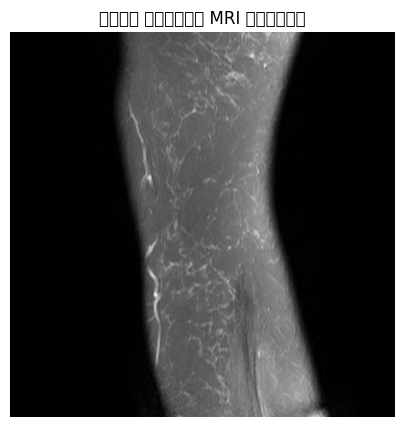

In [10]:
import os, glob
import pandas as pd
import numpy as np
import pydicom
import matplotlib.pyplot as plt

BASE = "/kaggle/input/competitions/rsna-knee-abnormality-detection"
ts = pd.read_csv(f"{BASE}/train_series.csv")

# একটা স্টাডি বাছি
uid = ts["StudyInstanceUID"].iloc[0]
rows = ts[ts["StudyInstanceUID"] == uid]

print("এই স্টাডিতে সিরিজ সংখ্যা:", len(rows))
print(rows[["Fluid_Sensitive", "Fat_Suppression", "Anatomical_Plane"]])
print()

# ফোল্ডার গঠন কেমন?
sid = rows["SeriesInstanceUID"].iloc[0]
path = f"{BASE}/train_series/{uid}/{sid}"
print("পথ আছে কিনা:", os.path.isdir(path))

files = sorted(glob.glob(f"{path}/*"))
print("স্লাইস সংখ্যা:", len(files))
print("প্রথম ফাইল:", os.path.basename(files[0]))
print()

# একটা স্লাইস পড়ি
d = pydicom.dcmread(files[len(files)//2])
arr = d.pixel_array
print("আকার:", arr.shape, "| dtype:", arr.dtype)
print("মান:", arr.min(), "থেকে", arr.max())
print()

for tag in ["Rows", "Columns", "PixelSpacing", "SliceThickness",
            "SeriesDescription", "InstanceNumber", "ImageLaterality"]:
    print(f"  {tag}: {getattr(d, tag, 'নাই')}")

plt.figure(figsize=(5,5))
plt.imshow(arr, cmap="gray")
plt.axis("off")
plt.title("একটা হাঁটুর MRI স্লাইস")
plt.show()

স্লাইস: 22
ক্রম: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22']


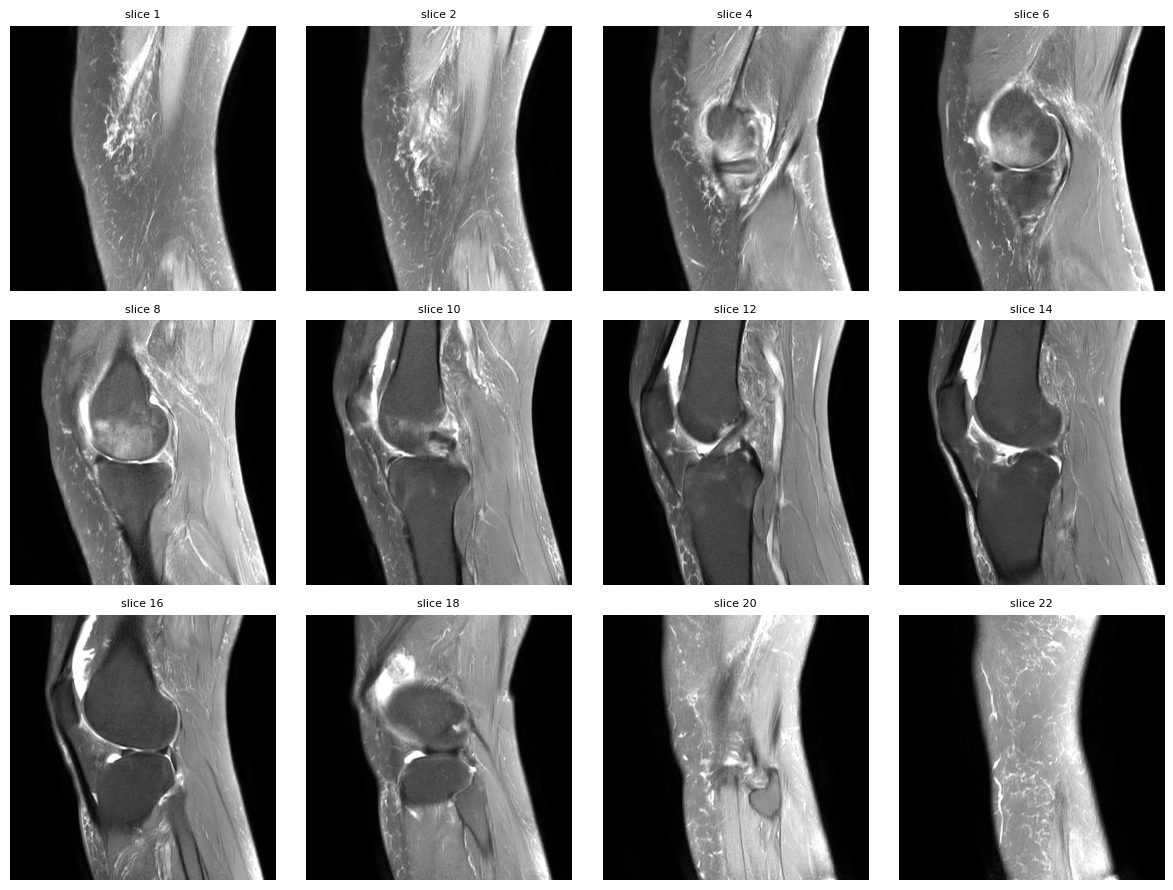


=== laterality খুঁজছি ===
{'Laterality': '', 'ImageLaterality': '—', 'BodyPartExamined': 'KNEE', 'SeriesDescription': 'DP SPIR CS_SAG', 'StudyDescription': '—', 'ProtocolName': '—'}
{'Laterality': '—', 'ImageLaterality': '—', 'BodyPartExamined': 'KNEE', 'SeriesDescription': 'SAG PD RIGHT', 'StudyDescription': '—', 'ProtocolName': '—'}
{'Laterality': '', 'ImageLaterality': '—', 'BodyPartExamined': 'EXTREMITY', 'SeriesDescription': 'Sag T2 FSE', 'StudyDescription': '—', 'ProtocolName': '—'}
{'Laterality': '—', 'ImageLaterality': '—', 'BodyPartExamined': 'KNEE', 'SeriesDescription': 'DummySeriesDesc!', 'StudyDescription': '—', 'ProtocolName': '—'}
{'Laterality': 'L', 'ImageLaterality': '—', 'BodyPartExamined': 'KNEE', 'SeriesDescription': 'pd_tse_fs_cor_384_p2_s2', 'StudyDescription': '—', 'ProtocolName': '—'}
{'Laterality': '—', 'ImageLaterality': '—', 'BodyPartExamined': '—', 'SeriesDescription': 'pd_tse_fs_sag_np', 'StudyDescription': '—', 'ProtocolName': '—'}


In [11]:
import os, glob
import numpy as np, pandas as pd, pydicom
import matplotlib.pyplot as plt

BASE = "/kaggle/input/competitions/rsna-knee-abnormality-detection"
ts = pd.read_csv(f"{BASE}/train_series.csv")

def load_series(uid, sid):
    """InstanceNumber দিয়ে ঠিকভাবে সাজানো একটা সিরিজ"""
    files = glob.glob(f"{BASE}/train_series/{uid}/{sid}/*")
    items = []
    for f in files:
        d = pydicom.dcmread(f)
        n = getattr(d, "InstanceNumber", None)
        items.append((n if n is not None else 0, d))
    items.sort(key=lambda x: x[0])
    return [d for _, d in items]

uid = ts["StudyInstanceUID"].iloc[0]
sag = ts[(ts["StudyInstanceUID"] == uid) & (ts["Anatomical_Plane"] == "Sagittal")]
sid = sag["SeriesInstanceUID"].iloc[0]

ds = load_series(uid, sid)
print("স্লাইস:", len(ds))
print("ক্রম:", [getattr(d, "InstanceNumber", "?") for d in ds])

# ১২টা স্লাইস একসাথে দেখি
idx = np.linspace(0, len(ds)-1, 12).astype(int)
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for ax, i in zip(axes.ravel(), idx):
    a = ds[i].pixel_array.astype(np.float32)
    lo, hi = np.percentile(a, [1, 99])       # স্ক্যানারভেদে মান বদলায়
    a = np.clip((a - lo) / (hi - lo + 1e-6), 0, 1)
    ax.imshow(a, cmap="gray"); ax.axis("off")
    ax.set_title(f"slice {getattr(ds[i],'InstanceNumber','?')}", fontsize=8)
plt.tight_layout(); plt.show()

# --- বাঁ/ডান কোথায় লেখা আছে খুঁজি ---
print("\n=== laterality খুঁজছি ===")
TAGS = ["Laterality", "ImageLaterality", "BodyPartExamined",
        "SeriesDescription", "StudyDescription", "ProtocolName"]
for j in range(6):
    u = ts["StudyInstanceUID"].iloc[j*500]
    s = ts[ts["StudyInstanceUID"] == u]["SeriesInstanceUID"].iloc[0]
    f = glob.glob(f"{BASE}/train_series/{u}/{s}/*")[0]
    d = pydicom.dcmread(f, stop_before_pixels=True)
    print({t: str(getattr(d, t, "—"))[:40] for t in TAGS})

In [12]:
import re, glob
import pandas as pd, pydicom

BASE = "/kaggle/input/competitions/rsna-knee-abnormality-detection"
train = pd.read_csv(f"{BASE}/train.csv")
ts = pd.read_csv(f"{BASE}/train_series.csv")

# --- ১. DICOM ট্যাগ + SeriesDescription (নমুনা ১৫০ স্টাডি, সময় বাঁচাতে) ---
def from_dicom(uid):
    for sid in ts[ts["StudyInstanceUID"] == uid]["SeriesInstanceUID"]:
        fs = glob.glob(f"{BASE}/train_series/{uid}/{sid}/*")
        if not fs: continue
        d = pydicom.dcmread(fs[0], stop_before_pixels=True)
        lat = str(getattr(d, "Laterality", "") or "").strip().upper()
        if lat in ("L", "R"): return lat
        desc = str(getattr(d, "SeriesDescription", "") or "").upper()
        if re.search(r"\b(RIGHT|RT|_R_|\bR\b)", desc): return "R"
        if re.search(r"\b(LEFT|LT|_L_|\bL\b)", desc):  return "L"
    return None

# --- ২. রিপোর্টের টেক্সট থেকে, বহু ভাষায় ---
RIGHT = r"(right knee|rodilla derecha|derecho|rechte knie|knie rechts|genou droit|sağ diz|desno koljeno|δεξι|дясно)"
LEFT  = r"(left knee|rodilla izquierda|izquierdo|linke knie|knie links|genou gauche|sol diz|lijevo koljeno|αριστερ|ляво)"

def from_report(txt):
    t = str(txt).lower()
    r, l = bool(re.search(RIGHT, t)), bool(re.search(LEFT, t))
    if r and not l: return "R"
    if l and not r: return "L"
    return None

sample = train.sample(150, random_state=0).copy()
sample["lat_dcm"] = sample["StudyInstanceUID"].apply(from_dicom)
sample["lat_rep"] = sample["Report"].apply(from_report)
sample["lat"] = sample["lat_dcm"].fillna(sample["lat_rep"])

print("DICOM থেকে পাওয়া গেছে:", sample["lat_dcm"].notna().sum(), "/ 150")
print("রিপোর্ট থেকে পাওয়া গেছে:", sample["lat_rep"].notna().sum(), "/ 150")
print("দুইটা মিলিয়ে:", sample["lat"].notna().sum(), "/ 150")
print()
print(sample["lat"].value_counts(dropna=False))

# দুই উৎস একমত কিনা
both = sample.dropna(subset=["lat_dcm", "lat_rep"])
if len(both):
    agree = (both["lat_dcm"] == both["lat_rep"]).mean()
    print(f"\nদুই উৎস দুটোই আছে এমন: {len(both)} টা, একমত: {agree:.1%}")

DICOM থেকে পাওয়া গেছে: 85 / 150
রিপোর্ট থেকে পাওয়া গেছে: 43 / 150
দুইটা মিলিয়ে: 102 / 150

lat
R       57
None    48
L       45
Name: count, dtype: int64

দুই উৎস দুটোই আছে এমন: 26 টা, একমত: 96.2%


In [1]:
import os, re, glob, time, json
import numpy as np, pandas as pd, pydicom, cv2

BASE = "/kaggle/input/competitions/rsna-knee-abnormality-detection"
OUT  = "/kaggle/working/cache"
os.makedirs(OUT, exist_ok=True)

N_SLICES, SIZE, PLANES = 12, 224, ["Sagittal", "Coronal", "Axial"]

train = pd.read_csv(f"{BASE}/train.csv")
ts    = pd.read_csv(f"{BASE}/train_series.csv")
REPORT = dict(zip(train["StudyInstanceUID"], train["Report"]))

RIGHT = r"(right knee|rodilla derecha|derecho|rechte knie|knie rechts|genou droit|sağ diz|desno koljeno|δεξι|дясно)"
LEFT  = r"(left knee|rodilla izquierda|izquierdo|linke knie|knie links|genou gauche|sol diz|lijevo koljeno|αριστερ|ляво)"

def lat_from_report(txt):
    t = str(txt).lower()
    r, l = bool(re.search(RIGHT, t)), bool(re.search(LEFT, t))
    return "R" if (r and not l) else ("L" if (l and not r) else None)

def lat_from_header(d):
    v = str(getattr(d, "Laterality", "") or "").strip().upper()
    if v in ("L", "R"): return v
    desc = str(getattr(d, "SeriesDescription", "") or "").upper()
    if re.search(r"(RIGHT|\bRT\b|_R_|\bR\b)", desc): return "R"
    if re.search(r"(LEFT|\bLT\b|_L_|\bL\b)", desc):  return "L"
    return None

def pick_series(rows):
    """প্রতি প্লেন থেকে একটা সিরিজ, Fluid_Sensitive=1 কে অগ্রাধিকার"""
    out = {}
    for p in PLANES:
        sub = rows[rows["Anatomical_Plane"] == p]
        if len(sub) == 0:
            out[p] = None; continue
        sub = sub.sort_values("Fluid_Sensitive", ascending=False)
        out[p] = sub["SeriesInstanceUID"].iloc[0]
    return out

def load_block(folder):
    """একটা সিরিজ → (12, 224, 224) uint8, সাথে header-laterality"""
    files = glob.glob(f"{folder}/*")
    if not files: return None, None

    # প্রথমে শুধু হেডার পড়ে সাজাই (পিক্সেল ছাড়া — অনেক দ্রুত)
    order = []
    for f in files:
        try:
            h = pydicom.dcmread(f, stop_before_pixels=True)
            order.append((float(getattr(h, "InstanceNumber", 0) or 0), f, h))
        except Exception:
            pass
    if not order: return None, None
    order.sort(key=lambda x: x[0])
    lat = lat_from_header(order[0][2])

    # মাঝের ৬০% থেকে ১২টা বাছি
    n = len(order)
    lo, hi = int(n * 0.2), max(int(n * 0.8), int(n * 0.2) + 1)
    mid = order[lo:hi] or order
    idx = np.linspace(0, len(mid) - 1, N_SLICES).round().astype(int)

    block = np.zeros((N_SLICES, SIZE, SIZE), np.uint8)
    for k, i in enumerate(idx):
        try:
            a = pydicom.dcmread(mid[i][1]).pixel_array.astype(np.float32)
            p1, p99 = np.percentile(a, [1, 99])
            a = np.clip((a - p1) / (p99 - p1 + 1e-6), 0, 1)
            block[k] = (cv2.resize(a, (SIZE, SIZE), interpolation=cv2.INTER_AREA) * 255).astype(np.uint8)
        except Exception:
            pass
    return block, lat

def build_study(uid):
    rows = ts[ts["StudyInstanceUID"] == uid]
    chosen = pick_series(rows)

    vol = np.zeros((len(PLANES), N_SLICES, SIZE, SIZE), np.uint8)
    lat, n_ok = None, 0
    for pi, p in enumerate(PLANES):
        sid = chosen[p]
        if sid is None: continue
        blk, l = load_block(f"{BASE}/train_series/{uid}/{sid}")
        if blk is None: continue
        vol[pi] = blk; n_ok += 1
        if lat is None: lat = l

    if lat is None:
        lat = lat_from_report(REPORT.get(uid, ""))
    if lat == "R":                      # ডান হাঁটু → আয়নায় উল্টাই
        vol = vol[:, :, :, ::-1].copy()

    return vol, lat, n_ok

# ---------- ৩০০টা দিয়ে পরীক্ষা ----------
uids = train["StudyInstanceUID"].tolist()
SUBSET = uids

log, t0 = [], time.time()
for i, uid in enumerate(SUBSET):
    try:
        vol, lat, n_ok = build_study(uid)
        np.save(f"{OUT}/{uid}.npy", vol)
        log.append({"StudyInstanceUID": uid, "lat": lat or "?",
                    "planes_ok": n_ok, "ok": 1})
    except Exception as e:
        log.append({"StudyInstanceUID": uid, "lat": "?",
                    "planes_ok": 0, "ok": 0, "err": str(e)[:80]})
    if (i + 1) % 300 == 0:
        el = time.time() - t0
        print(f"{i+1}/{len(SUBSET)}  |  {el/60:.1f} মিনিট", flush=True)

df = pd.DataFrame(log)
df.to_csv("/kaggle/working/cache_manifest.csv", index=False)

el = time.time() - t0
print(f"\nমোট সময়: {el/60:.1f} মিনিট")
print(f"সফল: {df['ok'].sum()} / 300")
print(f"তিন প্লেনই পাওয়া গেছে: {(df['planes_ok']==3).sum()}")
print(df["planes_ok"].value_counts().sort_index())
print(df["lat"].value_counts())
print(f"\nডিস্কে: {sum(os.path.getsize(f'{OUT}/{f}') for f in os.listdir(OUT))/1e9:.2f} GB")
print(f"পুরো ৪৪০৭-এর আনুমানিক সময়: {el/300*4407/3600:.1f} ঘণ্টা")
print(f"পুরো ৪৪০৭-এর আনুমানিক আকার: {sum(os.path.getsize(f'{OUT}/{f}') for f in os.listdir(OUT))/1e9/300*4407:.1f} GB")


import shutil
shutil.make_archive("/kaggle/working/knee_cache", "zip", OUT)
shutil.rmtree(OUT)
print("zip:", os.path.getsize("/kaggle/working/knee_cache.zip")/1e9, "GB")

300/4407  |  6.7 মিনিট
600/4407  |  13.9 মিনিট
900/4407  |  20.6 মিনিট


KeyboardInterrupt: 

In [ ]:
#import numpy as np, matplotlib.pyplot as plt, pandas as pd

#man = pd.read_csv("/kaggle/working/cache_manifest.csv")
#L = man[man["lat"]=="L"]["StudyInstanceUID"].iloc[0]
#R = man[man["lat"]=="R"]["StudyInstanceUID"].iloc[0]

#fig, axes = plt.subplots(2, 6, figsize=(15, 5))
#for row, (uid, tag) in enumerate([(L, "LEFT"), (R, "RIGHT-flipped")]):
 #   vol = np.load(f"/kaggle/working/cache/{uid}.npy")   # (3,12,224,224)
  #  for c in range(6):
   #     axes[row, c].imshow(vol[0, c*2], cmap="gray")   # Sagittal
    #    axes[row, c].axis("off")
    #axes[row, 0].set_title(tag, fontsize=9, loc="left")
#plt.tight_layout(); plt.show()

#print("আকার:", vol.shape, "| dtype:", vol.dtype, "| মান:", vol.min(), "-", vol.max())
#print("সম্পূর্ণ কালো ব্লক আছে কিনা:", int((vol.reshape(3,-1).max(1)==0).sum()), "/ 3")

In [ ]:
import os
print(os.listdir("/kaggle/input/"))

In [1]:
import os, glob, re, time
import numpy as np, pandas as pd, torch
import torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
from sklearn.metrics import roc_auc_score

BASE  = "/kaggle/input/competitions/rsna-knee-abnormality-detection"
CACHE = "/kaggle/input/datasets/prashantadas27/knee-cache-224"
dev   = "cuda"

# ---- cache কোথায় আছে খুঁজি ----
files = glob.glob(f"{CACHE}/**/*.npy", recursive=True)
if not files:
    import zipfile
    zipfile.ZipFile(glob.glob(f"{CACHE}/*.zip")[0]).extractall("/tmp/cache")
    CDIR = "/tmp/cache"
else:
    CDIR = os.path.dirname(files[0])
print("cache:", CDIR, "| ফাইল:", len(glob.glob(f"{CDIR}/*.npy")))

train = pd.read_csv(f"{BASE}/train.csv")
TARGETS = [c for c in train.columns if c not in ["StudyInstanceUID", "Report"]]

gold = train.dropna(subset=TARGETS, how="all")[["StudyInstanceUID"] + TARGETS].reset_index(drop=True)
print("গোল্ড:", len(gold))

cache: /kaggle/input/datasets/prashantadas27/knee-cache-224 | ফাইল: 4407
গোল্ড: 58


In [2]:
import re

NEG = r"(\bno\b|\bnot\b|without|absent|negative for|unremarkable|\bintact\b|preserved|\bnormal\b|free of|denies)"
STRONG = r"(large|massive|severe|extensive|marked|gross|significant|high.?grade|full.?thickness|complete)"
WEAK_W = r"(small|mild|minimal|trace|some|moderate|slight|minor|low.?grade|subtle|question|possible|suspicious)"

RULES = {
    "ACL":              (r"(\bacl\b|anterior cruciate)", r"(tear|torn|rupt|disrupt|discontinu)"),
    "MCL":              (r"(\bmcl\b|medial collateral)", r"(tear|torn|rupt|sprain|disrupt)"),
    "Medial Meniscus":  (r"medial meniscus|meniscus.{0,30}medial", r"(tear|torn|macerat|extrus|root)"),
    "Lateral Meniscus": (r"lateral meniscus|meniscus.{0,30}lateral", r"(tear|torn|macerat|extrus|root)"),
    "Medial OA":        (r"(medial compartment|medial femoral|medial tibial|tricompartment)", r"(chondr|cartilage|osteophyt|spur|joint space narrow|osteoarthr|degenerat)"),
    "Lateral OA":       (r"(lateral compartment|lateral femoral|lateral tibial|tricompartment)", r"(chondr|cartilage|osteophyt|spur|joint space narrow|osteoarthr|degenerat)"),
    "PF OA":            (r"(patellofemoral|patell|trochlea)", r"(chondr|cartilage|osteophyt|spur|osteoarthr|degenerat)"),
    "Effusion":         (r"effusion|hemarthros", r""),
    "Synovitis":        (r"(synovi|bursitis|pannus)", r""),
    "Baker's":          (r"(baker|popliteal cyst|semimembran)", r""),
    "Contusion":        (r"(contusion|bone bruise|marrow (edema|oedema)|bone edema)", r""),
    "Fracture":         (r"fractur", r""),
}

SECTION = {
    "medial":  r"medial compartment",
    "lateral": r"lateral compartment",
    "pf":      r"(patellofemoral|extensor mechanism)",
}
SEC_TGT = {"medial": "Medial OA", "lateral": "Lateral OA", "pf": "PF OA"}

def label_report(text):
    text = str(text)
    lines = [l.strip() for l in re.split(r"[\n]", text) if l.strip()]

    tagged, cur = [], None
    for l in lines:
        low = l.lower()
        for key, pat in SECTION.items():
            if re.search(pat, low):
                cur = key
        for s in re.split(r"[.;]", low):
            if s.strip():
                tagged.append((s.strip(), cur))

    out = {}
    for tgt, (anat, finding) in RULES.items():
        best = 0.0
        for s, sec in tagged:
            in_anat = bool(re.search(anat, s))
            in_sec  = (sec is not None and SEC_TGT.get(sec) == tgt)
            if not (in_anat or in_sec):
                continue
            if finding and not re.search(finding, s):
                continue
            if re.search(NEG, s):
                best = max(best, 0.05)
                continue
            if re.search(STRONG, s):
                best = max(best, 0.90)
            elif re.search(WEAK_W, s):
                best = max(best, 0.55)
            else:
                best = max(best, 0.75)
        out[tgt] = best if best > 0 else 0.15
    return out

# কাজ করছে কিনা দেখে নিই
print(label_report("Large joint effusion. ACL is intact. Medial meniscus tear."))

{'ACL': 0.15, 'MCL': 0.15, 'Medial Meniscus': 0.75, 'Lateral Meniscus': 0.15, 'Medial OA': 0.15, 'Lateral OA': 0.15, 'PF OA': 0.15, 'Effusion': 0.9, 'Synovitis': 0.15, "Baker's": 0.15, 'Contusion': 0.15, 'Fracture': 0.15}


In [3]:
!pip install -q langdetect
import re
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 0

def detect_lang(t):
    try: return detect(str(t))
    except: return "en"

# ============================================================
#  প্রতিটা ভাষার শব্দভাণ্ডার
# ============================================================

LANG_VOCAB = {}

# ---- স্প্যানিশ ----
LANG_VOCAB["es"] = dict(
    neg=r"(\bno\b|\bsin\b|ausencia|ausente|negativ|normal|conservad|íntegr|integr|indemne|preservad)",
    strong=r"(sever|important|marcad|extens|complet|gran|abundante|masiv|significativ)",
    weak=r"(leve|mínim|minim|pequeñ|moderad|discret|ligera|sutil|dudos|posible|sospech)",
    rules={
        "ACL":              (r"(lca|cruzado anterior)", r"(rotura|rotur|rupt|desgarr|discontinu|lesión)"),
        "MCL":              (r"(lcm|colateral medial|colateral interno)", r"(rotura|rotur|rupt|desgarr|esguince|lesión)"),
        "Medial Meniscus":  (r"menisco (medial|interno)", r"(rotura|rotur|desgarr|rupt|macerac)"),
        "Lateral Meniscus": (r"menisco (lateral|externo)", r"(rotura|rotur|desgarr|rupt|macerac)"),
        "Medial OA":        (r"(compartimento medial|femorotibial medial|interno)", r"(condropat|condral|cartílag|cartilag|osteofit|artrosis|degenerat)"),
        "Lateral OA":       (r"(compartimento lateral|femorotibial lateral|externo)", r"(condropat|condral|cartílag|cartilag|osteofit|artrosis|degenerat)"),
        "PF OA":            (r"(femoropatelar|patelofemoral|rotulian|tróclea|troclea|rótula|rotula)", r"(condropat|condral|cartílag|cartilag|osteofit|artrosis|degenerat)"),
        "Effusion":         (r"(derrame|hemartros)", r""),
        "Synovitis":        (r"(sinovitis|sinovial|bursitis)", r""),
        "Baker's":          (r"(quiste de baker|quiste poplíteo|quiste popliteo|baker)", r""),
        "Contusion":        (r"(contusión|contusion|edema óseo|edema oseo|edema de médula|edema medular)", r""),
        "Fracture":         (r"fractur", r""),
    },
    section={"medial": r"compartimento (medial|interno)", "lateral": r"compartimento (lateral|externo)", "pf": r"(femoropatelar|patelofemoral|aparato extensor)"},
)

# ---- তুর্কি ----
LANG_VOCAB["tr"] = dict(
    neg=r"(yok\b|değil|normal|sağlam|korunmuş|izlenmedi|doğal)",
    strong=r"(belirgin|yaygın|ciddi|tam kat|büyük|ileri)",
    weak=r"(hafif|minimal|az|şüpheli|olası|hafif derecede)",
    rules={
        "ACL":              (r"(önçb|ön çapraz|önçapraz)", r"(yırtık|rüptür|kopma|ayrışma)"),
        "MCL":              (r"(mkb|medial kollateral)", r"(yırtık|rüptür|kopma|burkulma)"),
        "Medial Meniscus":  (r"medial menisküs", r"(yırtık|rüptür|maserasyon)"),
        "Lateral Meniscus": (r"lateral menisküs", r"(yırtık|rüptür|maserasyon)"),
        "Medial OA":        (r"(medial kompartıman|medial kompartman)", r"(kıkırdak|kondral|osteofit|artroz|dejenerat)"),
        "Lateral OA":       (r"(lateral kompartıman|lateral kompartman)", r"(kıkırdak|kondral|osteofit|artroz|dejenerat)"),
        "PF OA":            (r"(patellofemoral|patella|troklea)", r"(kıkırdak|kondral|osteofit|artroz|dejenerat)"),
        "Effusion":         (r"efüzyon", r""),
        "Synovitis":        (r"(sinovit|bursit)", r""),
        "Baker's":          (r"(baker kist|popliteal kist)", r""),
        "Contusion":        (r"(kontüzyon|kemik iliği ödemi|kemik ödemi)", r""),
        "Fracture":         (r"kırık", r""),
    },
    section={"medial": r"medial kompart", "lateral": r"lateral kompart", "pf": r"(patellofemoral|ekstansör)"},
)

# ---- ক্রোয়েশিয়ান ----
LANG_VOCAB["hr"] = dict(
    neg=r"(\bnema\b|\bne\b|uredan|uredn|očuvan|negativ)",
    strong=r"(velik|značajan|ozbiljan|potpun|opsežan)",
    weak=r"(blag|minimal|mal|sumnjiv|moguć)",
    rules={
        "ACL":              (r"(prednji ukriženi|pul\b)", r"(ruptur|pretrganj|kidanj)"),
        "MCL":              (r"(medijalni kolateral)", r"(ruptur|pretrganj|distenzij)"),
        "Medial Meniscus":  (r"medijalni? meniskus", r"(ruptur|pretrganj)"),
        "Lateral Meniscus": (r"lateralni? meniskus", r"(ruptur|pretrganj)"),
        "Medial OA":        (r"medijalni odjeljak", r"(hrskavic|osteofit|artroz|degenerat)"),
        "Lateral OA":       (r"lateralni odjeljak", r"(hrskavic|osteofit|artroz|degenerat)"),
        "PF OA":            (r"(patelofemoral|patela|trohlea)", r"(hrskavic|osteofit|artroz|degenerat)"),
        "Effusion":         (r"izljev", r""),
        "Synovitis":        (r"sinovitis", r""),
        "Baker's":          (r"(bakerova cist|poplitealna cist)", r""),
        "Contusion":        (r"(kontuzij|koštani edem)", r""),
        "Fracture":         (r"(fraktur|prijelom)", r""),
    },
    section={"medial": r"medijalni odjeljak", "lateral": r"lateralni odjeljak", "pf": r"patelofemoral"},
)

# ---- গ্রিক ----
LANG_VOCAB["el"] = dict(
    neg=r"(όχι|δεν |φυσιολογικ|ακέραι|χωρίς)",
    strong=r"(εκτεταμέν|σοβαρ|μεγάλ|πλήρ)",
    weak=r"(ήπι|ελάχιστ|μικρ|ύποπτ|πιθαν)",
    rules={
        "ACL":              (r"(πρόσθιος χιαστ)", r"(ρήξ|διάσπασ)"),
        "MCL":              (r"(έσω πλάγι)", r"(ρήξ|διάταση)"),
        "Medial Meniscus":  (r"έσω μηνίσκ", r"ρήξ"),
        "Lateral Meniscus": (r"έξω μηνίσκ", r"ρήξ"),
        "Medial OA":        (r"έσω διαμέρισμα", r"(χόνδρ|οστεόφυτ|αρθρίτ|εκφυλισ)"),
        "Lateral OA":       (r"έξω διαμέρισμα", r"(χόνδρ|οστεόφυτ|αρθρίτ|εκφυλισ)"),
        "PF OA":            (r"επιγονατιδομηριαί", r"(χόνδρ|οστεόφυτ|αρθρίτ|εκφυλισ)"),
        "Effusion":         (r"(συλλογ|έκχυμα)", r""),
        "Synovitis":        (r"συνοβίτιδ", r""),
        "Baker's":          (r"(κύστη baker|ιγνυακή κύστη)", r""),
        "Contusion":        (r"(θλάσ|οίδημα μυελ)", r""),
        "Fracture":         (r"κάταγμα", r""),
    },
    section={"medial": r"έσω διαμέρισμα", "lateral": r"έξω διαμέρισμα", "pf": r"επιγονατιδομηριαί"},
)

# ---- জার্মান ----
LANG_VOCAB["de"] = dict(
    neg=r"(\bkein|\bnicht\b|unauffällig|intakt|regelrecht)",
    strong=r"(ausgeprägt|groß|schwer|vollständig)",
    weak=r"(gering|minimal|leicht|fraglich|möglich)",
    rules={
        "ACL":              (r"(vorderes kreuzband|vkb)", r"(ruptur|riss)"),
        "MCL":              (r"(mediales kollateralband)", r"(ruptur|riss)"),
        "Medial Meniscus":  (r"(innenmeniskus|medialer meniskus)", r"(ruptur|riss)"),
        "Lateral Meniscus": (r"(außenmeniskus|lateraler meniskus)", r"(ruptur|riss)"),
        "Medial OA":        (r"medial.{0,10}kompart", r"(knorpel|osteophyt|arthros|degenerat)"),
        "Lateral OA":       (r"lateral.{0,10}kompart", r"(knorpel|osteophyt|arthros|degenerat)"),
        "PF OA":            (r"(patellofemoral|patella|trochlea)", r"(knorpel|osteophyt|arthros|degenerat)"),
        "Effusion":         (r"erguss", r""),
        "Synovitis":        (r"synovitis", r""),
        "Baker's":          (r"(bakerzyste|poplitealzyste)", r""),
        "Contusion":        (r"(kontusion|knochenmarködem)", r""),
        "Fracture":         (r"fraktur", r""),
    },
    section={"medial": r"medial.{0,10}kompart", "lateral": r"lateral.{0,10}kompart", "pf": r"patellofemoral"},
)

# ---- বুলগেরিয়ান ----
LANG_VOCAB["bg"] = dict(
    neg=r"(няма|\bне\b|нормал|запазен|без\b)",
    strong=r"(изразен|голям|тежък|пълен)",
    weak=r"(лек\b|минимал|малък|съмнителен|възможен)",
    rules={
        "ACL":              (r"предна кръстна", r"(руптур|скъсван)"),
        "MCL":              (r"медиална колатерал", r"(руптур|скъсван)"),
        "Medial Meniscus":  (r"медиален менискус", r"(руптур|скъсван)"),
        "Lateral Meniscus": (r"латерален менискус", r"(руптур|скъсван)"),
        "Medial OA":        (r"медиален компартмент", r"(хрущял|остеофит|артроз|дегенерат)"),
        "Lateral OA":       (r"латерален компартмент", r"(хрущял|остеофит|артроз|дегенерат)"),
        "PF OA":            (r"пателофеморал", r"(хрущял|остеофит|артроз|дегенерат)"),
        "Effusion":         (r"излив", r""),
        "Synovitis":        (r"синовит", r""),
        "Baker's":          (r"(киста на бейк|поплитеална киста)", r""),
        "Contusion":        (r"(контузия|костномозъчен оток)", r""),
        "Fracture":         (r"фрактура", r""),
    },
    section={"medial": r"медиален компартмент", "lateral": r"латерален компартмент", "pf": r"пателофеморал"},
)

# ---- ডাচ ----
LANG_VOCAB["nl"] = dict(
    neg=r"(\bgeen\b|\bniet\b|normaal|intact|onopvallend)",
    strong=r"(uitgebreid|ernstig|groot|volledig)",
    weak=r"(licht|minimaal|klein|verdacht|mogelijk)",
    rules={
        "ACL":              (r"voorste kruisband", r"(ruptuur|scheur)"),
        "MCL":              (r"mediale collaterale band", r"(ruptuur|scheur)"),
        "Medial Meniscus":  (r"mediale meniscus", r"(ruptuur|scheur)"),
        "Lateral Meniscus": (r"laterale meniscus", r"(ruptuur|scheur)"),
        "Medial OA":        (r"mediaal compartiment", r"(kraakbeen|osteofyt|artros|degenerat)"),
        "Lateral OA":       (r"lateraal compartiment", r"(kraakbeen|osteofyt|artros|degenerat)"),
        "PF OA":            (r"(patellofemoraal|patella|trochlea)", r"(kraakbeen|osteofyt|artros|degenerat)"),
        "Effusion":         (r"(effusie|gewrichtsvocht)", r""),
        "Synovitis":        (r"synovitis", r""),
        "Baker's":          (r"(baker.?cyste|poplitea.?cyste)", r""),
        "Contusion":        (r"(contusie|beenmergoedeem)", r""),
        "Fracture":         (r"fractuur", r""),
    },
    section={"medial": r"mediaal compartiment", "lateral": r"lateraal compartiment", "pf": r"patellofemoraal"},
)

# ---- ফরাসি ----
LANG_VOCAB["fr"] = dict(
    neg=r"(pas de |aucun|\bsans\b|normal|intact|préservé)",
    strong=r"(important|sévère|étendu|complet|volumineux)",
    weak=r"(léger|minime|petit|discret|suspect|possible)",
    rules={
        "ACL":              (r"(ligament croisé antérieur|lca)", r"(rupture|déchirure)"),
        "MCL":              (r"(ligament collatéral médial|lli)", r"(rupture|déchirure|entorse)"),
        "Medial Meniscus":  (r"ménisque (médial|interne)", r"(rupture|déchirure)"),
        "Lateral Meniscus": (r"ménisque (latéral|externe)", r"(rupture|déchirure)"),
        "Medial OA":        (r"compartiment médial", r"(cartilag|chondr|ostéophyt|arthros|dégénérat)"),
        "Lateral OA":       (r"compartiment latéral", r"(cartilag|chondr|ostéophyt|arthros|dégénérat)"),
        "PF OA":            (r"(fémoro.?patellaire|patell|trochlé)", r"(cartilag|chondr|ostéophyt|arthros|dégénérat)"),
        "Effusion":         (r"épanchement", r""),
        "Synovitis":        (r"synovite", r""),
        "Baker's":          (r"(kyste de baker|kyste poplité)", r""),
        "Contusion":        (r"(contusion|œdème osseux)", r""),
        "Fracture":         (r"fracture", r""),
    },
    section={"medial": r"compartiment médial", "lateral": r"compartiment latéral", "pf": r"fémoro.?patellaire"},
)

# ============================================================
#  একটাই ফাংশন — ভাষা দেখে নিয়ম বেছে নেয়
# ============================================================
def label_report_lang(text, lg):
    if lg in LANG_VOCAB:
        v = LANG_VOCAB[lg]
        neg, strong, weak, rules, section = v["neg"], v["strong"], v["weak"], v["rules"], v["section"]
    else:                                   # ইংরেজি + যা মেলেনি
        neg, strong, weak, rules, section = NEG, STRONG, WEAK_W, RULES, SECTION

    lines = [l.strip() for l in re.split(r"[\n]", str(text)) if l.strip()]
    tagged, cur = [], None
    for l in lines:
        low = l.lower()
        for key, pat in section.items():
            if re.search(pat, low): cur = key
        for s in re.split(r"[.;]", low):
            if s.strip(): tagged.append((s.strip(), cur))

    out = {}
    for tgt, (anat, finding) in rules.items():
        best = 0.0
        for s, sec in tagged:
            if not (re.search(anat, s) or (sec and SEC_TGT.get(sec) == tgt)):
                continue
            if finding and not re.search(finding, s):
                continue
            if re.search(neg, s):
                best = max(best, 0.05); continue
            if re.search(strong, s):   best = max(best, 0.90)
            elif re.search(weak, s):   best = max(best, 0.55)
            else:                      best = max(best, 0.75)
        out[tgt] = best if best > 0 else 0.15
    return out

print("সব ভাষা প্রস্তুত:", ["en"] + list(LANG_VOCAB.keys()))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 4.1 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
সব ভাষা প্রস্তুত: ['en', 'es', 'tr', 'hr', 'el', 'de', 'bg', 'nl', 'fr']


In [4]:
import time, random, numpy as np, pandas as pd, torch
import torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
from sklearn.metrics import roc_auc_score

# ---------- সব এলোমেলো উৎস ফিক্স করি — ন্যায্য তুলনার জন্য ----------
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# ---------- ভাষা অনুযায়ী weak label ----------
train["lang"] = train["Report"].apply(detect_lang)
print(train["lang"].value_counts().head(10))

weak = pd.DataFrame([label_report_lang(r, l) for r, l in zip(train["Report"], train["lang"])])
weak.insert(0, "StudyInstanceUID", train["StudyInstanceUID"].values)

gold_ids = set(gold["StudyInstanceUID"])
weak_tr  = weak[~weak["StudyInstanceUID"].isin(gold_ids)].reset_index(drop=True)
print("ট্রেনিং:", len(weak_tr), "| ভ্যালিডেশন:", len(gold))

# ---------- ডেটা ----------
class KneeDS(Dataset):
    def __init__(self, df, train=True):
        self.uids = df["StudyInstanceUID"].values
        self.y = df[TARGETS].values.astype(np.float32)
        self.train = train
    def __len__(self): return len(self.uids)
    def __getitem__(self, i):
        v = np.load(f"{CDIR}/{self.uids[i]}.npy").astype(np.float32) / 255.
        if self.train and np.random.rand() < 0.5:
            v = v[:, :, :, ::-1].copy()
        return torch.from_numpy(v), torch.from_numpy(self.y[i])

# ---------- মডেল ----------
class Net(nn.Module):
    def __init__(self, name="efficientnet_b0", drop=0.2):
        super().__init__()
        self.bb = timm.create_model(name, pretrained=True, in_chans=1, num_classes=0)
        self.drop = nn.Dropout(drop)
        self.head = nn.Linear(self.bb.num_features, len(TARGETS))
    def forward(self, x):
        B, P, S, H, W = x.shape
        f = self.bb(x.reshape(B*P*S, 1, H, W)).reshape(B, P*S, -1)
        return self.head(self.drop(f.mean(1)))

def evaluate(model, loader):
    model.eval(); ps, ys = [], []
    with torch.no_grad():
        for x, y in loader:
            with torch.autocast("cuda", torch.float16):
                ps.append(torch.sigmoid(model(x.to("cuda"))).float().cpu().numpy())
            ys.append(y.numpy())
    p, y = np.concatenate(ps), np.concatenate(ys)
    aucs = [roc_auc_score(y[:,i], p[:,i]) for i in range(len(TARGETS)) if len(set(y[:,i]))>1]
    return float(np.mean(aucs)), aucs

g = torch.Generator(); g.manual_seed(SEED)
tr_dl = DataLoader(KneeDS(weak_tr, True), batch_size=4, shuffle=True,  num_workers=2, drop_last=True, generator=g)
va_dl = DataLoader(KneeDS(gold, False),   batch_size=4, shuffle=False, num_workers=2)

model  = Net().to("cuda")
opt    = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=10)
scaler = torch.amp.GradScaler()

# label smoothing: ০/১ এর বদলে ০.০৫/০.৯৫ এর দিকে টানি, overconfidence কমায়
def smooth(y, eps=0.05):
    return y * (1 - eps) + 0.5 * eps

# ---------- ট্রেনিং ----------
EPOCHS, best, patience, bad = 10, 0, 4, 0
for ep in range(EPOCHS):
    model.train(); t0, tot = time.time(), 0
    for i, (x, y) in enumerate(tr_dl):
        x, y = x.to("cuda"), smooth(y).to("cuda")
        with torch.autocast("cuda", torch.float16):
            loss = F.binary_cross_entropy_with_logits(model(x), y)
        opt.zero_grad(); scaler.scale(loss).backward()
        scaler.step(opt); scaler.update()
        tot += loss.item()
        if i % 200 == 0:
            print(f"  ep{ep} {i}/{len(tr_dl)} loss {loss.item():.4f}", flush=True)
    sched.step()

    auc, per = evaluate(model, va_dl)
    print(f"\nEPOCH {ep} | গোল্ড AUC {auc:.4f} | lr {sched.get_last_lr()[0]:.2e} | {(time.time()-t0)/60:.1f} মিনিট")
    for t, a in zip(TARGETS, per): print(f"    {t:<18} {a:.3f}")

    if auc > best:
        best, bad = auc, 0
        torch.save(model.state_dict(), "/kaggle/working/best.pt")
        print(f"    ★ নতুন সেরা: {best:.4f} — সেভ হলো")
    else:
        bad += 1
        print(f"    (উন্নতি নাই, {bad}/{patience})")
        if bad >= patience:
            print(f"    থেমে গেলাম — {patience} epoch ধরে উন্নতি নাই")
            break

print(f"\nসর্বোচ্চ: {best:.4f}")

lang
en    1736
es     682
tr     546
hr     406
el     321
de     262
bg     220
nl     153
fr      81
Name: count, dtype: int64
ট্রেনিং: 4349 | ভ্যালিডেশন: 58


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

  ep0 0/1087 loss 0.7089
  ep0 200/1087 loss 0.5871
  ep0 400/1087 loss 0.5606
  ep0 600/1087 loss 0.5572
  ep0 800/1087 loss 0.5982
  ep0 1000/1087 loss 0.5057

EPOCH 0 | গোল্ড AUC 0.7208 | lr 2.93e-04 | 7.2 মিনিট
    ACL                0.817
    MCL                0.707
    Medial Meniscus    0.537
    Lateral Meniscus   0.755
    Medial OA          0.669
    Lateral OA         0.654
    PF OA              0.681
    Effusion           0.901
    Synovitis          0.538
    Baker's            0.882
    Contusion          0.697
    Fracture           0.811
    ★ নতুন সেরা: 0.7208 — সেভ হলো
  ep1 0/1087 loss 0.5936
  ep1 200/1087 loss 0.5168
  ep1 400/1087 loss 0.5143
  ep1 600/1087 loss 0.4820
  ep1 800/1087 loss 0.5480
  ep1 1000/1087 loss 0.5369

EPOCH 1 | গোল্ড AUC 0.7294 | lr 2.71e-04 | 7.0 মিনিট
    ACL                0.824
    MCL                0.760
    Medial Meniscus    0.574
    Lateral Meniscus   0.694
    Medial OA          0.693
    Lateral OA         0.671
    PF OA     